<a href="https://colab.research.google.com/github/Naveen-gale/ml-part-4/blob/main/house_price_predml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sas
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
file = files.upload()

Saving house_prices.csv to house_prices.csv


In [15]:
df = pd.read_csv('house_prices.csv')

In [16]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [17]:
df.isnull().sum()

,0
Index,0
Title,0
Description,3023
Amount(in rupees),0
Price (in rupees),17665
location,0
Carpet Area,80673
Status,615
Floor,7077
Transaction,83


In [18]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [9]:
df[['Index','Price (in rupees)','Dimensions','Plot Area']].describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN


In [19]:
df.drop(columns=["Dimensions","Plot Area"], inplace=True)

In [20]:
y= df['Price (in rupees)']


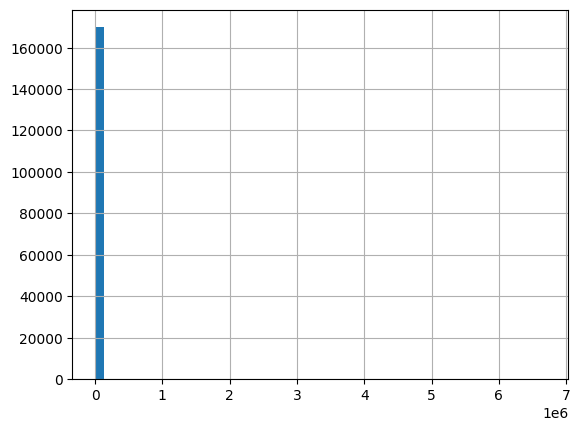

In [23]:
df["Price (in rupees)"].hist(bins=50)
plt.show()

In [24]:
import numpy as np

df["Price (in rupees)"] = np.log1p(df["Price (in rupees)"])

In [25]:
df.drop(
    columns=["Index","Title","Description","Society"],
    inplace=True
)

In [28]:
df.isnull().sum().sort_values(ascending=False)

,0
Super Area,93631
Car Parking,90950
Carpet Area,76235
overlooking,70646
facing,62052
Ownership,58237
Balcony,45062
Floor,6843
Furnishing,2060
Bathroom,754


In [27]:
df = df.dropna(subset=['Price (in rupees)'])

In [29]:
(df.isnull().sum()/len(df))*100

,0
Amount(in rupees),0.000000
Price (in rupees),0.000000
location,0.000000
Carpet Area,44.879493
Status,0.350276
Floor,4.028469
Transaction,0.003532
Furnishing,1.212721
facing,36.529971
overlooking,41.589253


In [30]:
drop_cols = [
    "Super Area",
    "Car Parking"
]

df.drop(columns=drop_cols, inplace=True)

In [31]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].fillna(df[col].mode()[0])

In [32]:
df.isnull().sum()

,0
Amount(in rupees),0
Price (in rupees),0
location,0
Carpet Area,0
Status,0
Floor,0
Transaction,0
Furnishing,0
facing,0
overlooking,0


In [33]:
df[["Amount(in rupees)", "Price (in rupees)"]].head(20)

,Amount(in rupees),Price (in rupees)
0,42 Lac,8.699681
1,98 Lac,9.532424
2,1.40 Cr,9.770013
4,1.60 Cr,9.842941
5,45 Lac,8.797700
6,16.5 Lac,7.839526
7,60 Lac,9.253017
8,60 Lac,9.210440
9,1.60 Cr,9.319284
10,1.40 Cr,9.407140


In [34]:
df.drop(
    columns=["Amount(in rupees)"],
    inplace=True
)

In [35]:
y = df["Price (in rupees)"]

In [36]:
X = df.drop(
    columns=["Price (in rupees)"]
)

In [37]:
df["Carpet Area"].head()

,Carpet Area
0,500 sqft
1,473 sqft
2,779 sqft
4,635 sqft
5,1000 sqft


In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print(r2_score(y_test,pred))
print(model.score(X_test,y_test))

0.7989520733912975
0.7989520733912975


In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in X.select_dtypes(include="object"):
    X[col] = le.fit_transform(X[col].astype(str))

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169866 entries, 0 to 187530
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Price (in rupees)  169866 non-null  float64
 1   location           169866 non-null  object 
 2   Carpet Area        169866 non-null  object 
 3   Status             169866 non-null  object 
 4   Floor              169866 non-null  object 
 5   Transaction        169866 non-null  object 
 6   Furnishing         169866 non-null  object 
 7   facing             169866 non-null  object 
 8   overlooking        169866 non-null  object 
 9   Bathroom           169866 non-null  object 
 10  Balcony            169866 non-null  object 
 11  Ownership          169866 non-null  object 
dtypes: float64(1), object(11)
memory usage: 16.8+ MB


In [43]:
df.head()

,Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership
0,8.699681,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,East,Main Road,1,2,Freehold
1,9.532424,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,2,2,Freehold
2,9.770013,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,2,2,Freehold
4,9.842941,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",2,2,Co-operative Society
5,8.797700,thane,1000 sqft,Ready to Move,2 out of 7,Resale,Unfurnished,East,"Garden/Park, Main Road",1,1,Co-operative Society


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

In [46]:
models = {
    "Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [47]:
for name, model in models.items():
    model.fit(X_train,y_train)
    print(name + " trained")
    predi= model.predict(X_test)
    print(r2_score(y_test,predi))

Linear trained
0.12685501393620857
Decision Tree trained
0.6888788714290467
Random Forest trained
0.7989520733912975
Extra Trees trained
0.7867867014290224
Gradient Boosting trained
0.595107432574217


In [48]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
0,location,0.567773
8,Bathroom,0.214644
3,Floor,0.081492
1,Carpet Area,0.060167
7,overlooking,0.019696
9,Balcony,0.018144
5,Furnishing,0.015346
6,facing,0.014092
4,Transaction,0.007988
10,Ownership,0.000659


In [53]:
from sklearn.preprocessing import OneHotEncoder
X= pd.get_dummies(X, columns=['location'])

In [54]:
df.columns

Index(['Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Bathroom',
       'Balcony', 'Ownership'],
      dtype='object')

In [57]:
df['Carpet Area'].head(20)

,Carpet Area
0,500.0
1,473.0
2,779.0
4,635.0
5,1000.0
6,550.0
7,1000.0
8,1000.0
9,900.0
10,950.0


In [56]:
df["Carpet Area"] = (
    df["Carpet Area"]
    .str.extract(r'(\d+)')
    .astype(float)
)

In [61]:
X= pd.get_dummies(X, drop_first=True)

In [62]:
from sklearn.ensemble import ExtraTreesRegressor
model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X,y)

ExtraTreesRegressor()

In [63]:
y_pred = model.predict(X)

In [64]:
accu = r2_score(y,y_pred)

In [65]:
accu

0.9626541713086606